## Feature engineering

### Handle missing values

In [2]:
import pandas as pd 
import numpy as np 

In [3]:
def titanic_data(TITANIC_PATH):
    return pd.read_csv(TITANIC_PATH)

titanic = pd.read_csv("titanic.csv")
titanic.head(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
titanic['Name'].value_counts()

Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64

In [6]:
titanic['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [14]:
titanic['Ticket'].value_counts()


Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

In [15]:

titanic['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [16]:
titanic['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [17]:

df = pd.DataFrame(titanic)
print("Original DataFrame with Missing Values:")
print(df)

Original DataFrame with Missing Values:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                           

In [18]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [19]:

mean_age = df['Age'].mean()
mean_age = round(mean_age)
print("Mean of ages = ", mean_age)

Mean of ages =  30


In [22]:
df['Age'] = df['Age'].fillna(mean_age)

In [23]:
print(df['Age'].isnull().sum())

0


In [24]:
titanic_new = titanic.drop(columns= "Cabin")

In [25]:

titanic_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [26]:

df = pd.DataFrame(titanic_new)
df.head(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


## Handle categorical values

In [30]:

mode_titanic = df['Embarked'].mode()
print("Mode from Embarked of titanic = ", mode_titanic[0])

Mode from Embarked of titanic =  S


In [33]:

df['Embarked'] = df['Embarked'].fillna(mode_titanic[0])

In [34]:
print(df['Embarked'].isnull().sum())

0


## Data scaling

In [35]:

df['Fare'] = df['Fare'] * 10000

In [36]:
df['Fare'].head(10)

0     72500.0
1    712833.0
2     79250.0
3    531000.0
4     80500.0
5     84583.0
6    518625.0
7    210750.0
8    111333.0
9    300708.0
Name: Fare, dtype: float64

In [38]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

# Initialize scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
maxabs_scaler = MaxAbsScaler()

# Apply scalers
df_standard = pd.DataFrame(standard_scaler.fit_transform(df[["Fare"]]), columns=["Fare"])
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df[["Fare"]]), columns=["Fare"])
df_robust = pd.DataFrame(robust_scaler.fit_transform(df[["Fare"]]), columns=["Fare"])
df_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(df[["Fare"]]), columns=["Fare"])

# Log Transformation (Handling zero by adding 1)
df_log = np.log1p(df["Fare"])

# Display results
print("\nStandard Scaled Data:\n", df_standard)
print("\nMinMax Scaled Data:\n", df_minmax)


Standard Scaled Data:
          Fare
0   -0.502445
1    0.786845
2   -0.488854
3    0.420730
4   -0.486337
..        ...
886 -0.386671
887 -0.044381
888 -0.176263
889 -0.044381
890 -0.492378

[891 rows x 1 columns]

MinMax Scaled Data:
          Fare
0    0.014151
1    0.139136
2    0.015469
3    0.103644
4    0.015713
..        ...
886  0.025374
887  0.058556
888  0.045771
889  0.058556
890  0.015127

[891 rows x 1 columns]


In [39]:
print("\nRobust Scaled Data:\n", df_robust)
print("\nMaxAbs Scaled Data:\n", df_maxabs)


Robust Scaled Data:
          Fare
0   -0.312011
1    2.461242
2   -0.282777
3    1.673732
4   -0.277363
..        ...
886 -0.062981
887  0.673281
888  0.389604
889  0.673281
890 -0.290356

[891 rows x 1 columns]

MaxAbs Scaled Data:
          Fare
0    0.014151
1    0.139136
2    0.015469
3    0.103644
4    0.015713
..        ...
886  0.025374
887  0.058556
888  0.045771
889  0.058556
890  0.015127

[891 rows x 1 columns]


In [40]:
print("\nLog Transformed Data:\n", df_log)


Log Transformed Data:
 0      11.191356
1      13.477004
2      11.280375
3      13.182519
4      11.296025
         ...    
886    11.775297
887    12.611541
888    12.365215
889    12.611541
890    11.258046
Name: Fare, Length: 891, dtype: float64


## Handling Outliers


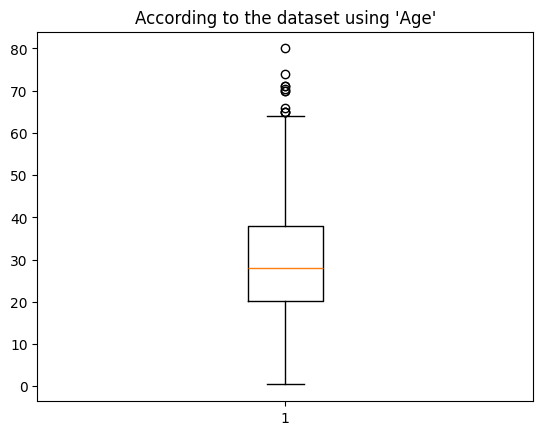

In [44]:
import matplotlib.pyplot as plt

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

plt.boxplot(df['Age'].dropna())
plt.title("According to the dataset using 'Age'")

plt.show()

###### too many outliers so removing them 

In [46]:
print(f"Q1 = {Q1} and Q3 = {Q3}")

Q1 = 20.125 and Q3 = 38.0


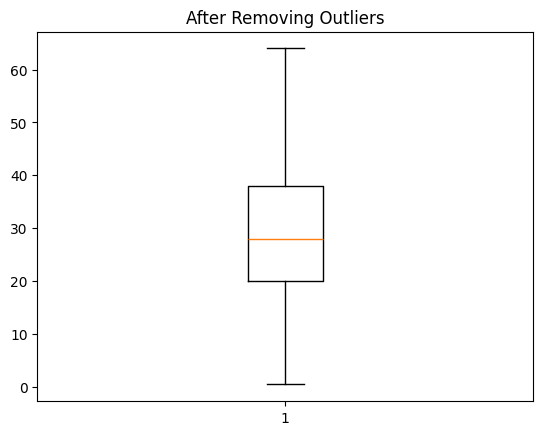

In [47]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

plt.boxplot(df_filtered['Age'])
plt.title("After Removing Outliers")

plt.show()

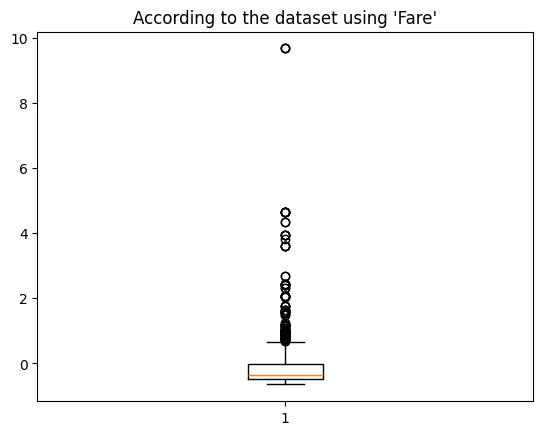

In [48]:
Q11 = df_standard['Fare'].quantile(0.25)
Q13 = df_standard['Fare'].quantile(0.75)
IQR1 = Q13 - Q11

plt.boxplot(df_standard['Fare'])
plt.title("According to the dataset using 'Fare'")

plt.show()

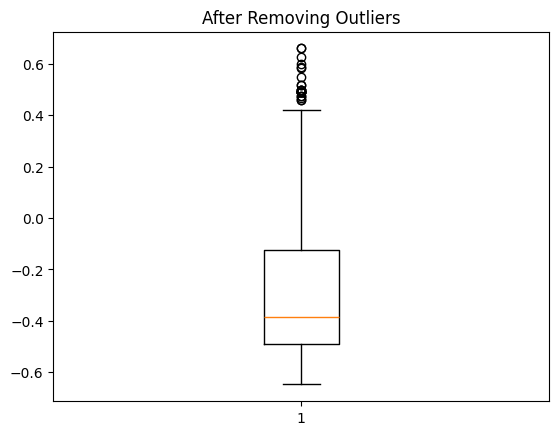

In [49]:
lower_bound = Q11 - 1.5 * IQR1
upper_bound = Q13 + 1.5 * IQR1

df_filtered_Fare = df_standard[(df_standard['Fare'] >= lower_bound) & (df_standard['Fare'] <= upper_bound)]

plt.boxplot(df_filtered_Fare['Fare'])
plt.title("After Removing Outliers")

plt.show()

In [50]:
titanic_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [51]:
titanic_new_1 = titanic_new.drop(columns= "Name")

In [52]:
titanic_new_1 = titanic_new_1.drop(columns= "Sex")

In [53]:
titanic_new_1 = titanic_new_1.drop(columns= "Ticket")

In [54]:
titanic_new_1 = titanic_new_1.drop(columns= "Embarked")

In [55]:
titanic_new_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


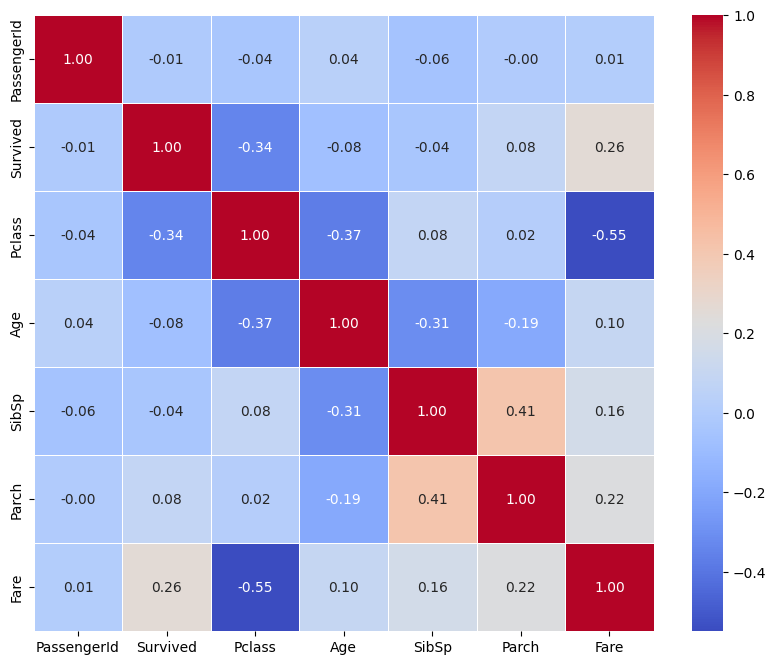

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [56]:
import seaborn as sns

corr_matrix = titanic_new_1.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()

corr_threshold = 0.9
to_drop = [column for column in corr_matrix.columns if any(abs(corr_matrix[column]) > corr_threshold)]
print(to_drop)

X = titanic.drop("Fare", axis=1)
y = titanic['Fare']

In [58]:
titanic_num = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
titanic_cat = X.select_dtypes(include=['object', 'string']).columns

# Print out the column names to verify
print("Numerical columns:", titanic_num)
print("Categorical columns:", titanic_cat)

Numerical columns: Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch'], dtype='str')
Categorical columns: Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


from sklearn.impute import SimpleImputer

## Define the numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values with median
    ('scaler', StandardScaler())  # Scale the numerical features
])

# Define the categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing categorical values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode categorical features
])

# Combine both pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), titanic_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), titanic_cat)
    ]
)

In [60]:
# Apply the transformation to the features (X)
X_transformed = preprocessor.fit_transform(X)

num_columns = titanic_num

cat_columns = preprocessor.named_transformers_["cat"].get_feature_names_out(titanic_cat)

all_columns = list(num_columns) + list(cat_columns)
X_transformed_df = pd.DataFrame(X_transformed, columns=all_columns)

# Display the transformed dataset
print(X_transformed_df.head())

   PassengerId  Survived    Pclass       Age     SibSp     Parch  \
0    -1.730108 -0.789272  0.827377 -0.530377  0.432793 -0.473674   
1    -1.726220  1.266990 -1.566107  0.571831  0.432793 -0.473674   
2    -1.722332  1.266990  0.827377 -0.254825 -0.474545 -0.473674   
3    -1.718444  1.266990 -1.566107  0.365167  0.432793 -0.473674   
4    -1.714556 -0.789272  0.827377  0.365167 -0.474545 -0.473674   

   Name_Abbing, Mr. Anthony  Name_Abbott, Mr. Rossmore Edward  \
0                       0.0                               0.0   
1                       0.0                               0.0   
2                       0.0                               0.0   
3                       0.0                               0.0   
4                       0.0                               0.0   

   Name_Abbott, Mrs. Stanton (Rosa Hunt)  Name_Abelson, Mr. Samuel  ...  \
0                                    0.0                       0.0  ...   
1                                    0.0          

In [64]:

from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split

# Dataset
X = X_transformed_df

# Handle missing values
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# LassoCV model
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)

# Train model
lasso.fit(X_train, y_train)

# Results
print(f"Best alpha: {lasso.alpha_}")

# Feature names (Important fix)
selected_features = X_transformed_df.columns[lasso.coef_ != 0]

print("Selected features:", selected_features)

Best alpha: 1.6196720925405297
Selected features: Index(['Pclass', 'SibSp', 'Parch', 'Name_Andrews, Mr. Thomas Jr',
       'Name_Baxter, Mr. Quigg Edmond', 'Name_Burns, Miss. Elizabeth Margaret',
       'Name_Carlsson, Mr. Frans Olof', 'Name_Fry, Mr. Richard',
       'Name_Harrison, Mr. William', 'Name_Lurette, Miss. Elise',
       'Name_Newell, Miss. Marjorie', 'Name_Parr, Mr. William Henry Marsh',
       'Name_Perreault, Miss. Anne',
       'Name_Ryerson, Miss. Susan Parker "Suzette"',
       'Name_Widener, Mr. Harry Elkins', 'Sex_female', 'Sex_male',
       'Ticket_110152', 'Ticket_112050', 'Ticket_112058', 'Ticket_112059',
       'Ticket_113503', 'Ticket_113760', 'Ticket_113781', 'Ticket_11767',
       'Ticket_1601', 'Ticket_17421', 'Ticket_19928', 'Ticket_19943',
       'Ticket_19950', 'Ticket_220845', 'Ticket_239853', 'Ticket_24160',
       'Ticket_36928', 'Ticket_36973', 'Ticket_695', 'Ticket_PC 17582',
       'Ticket_PC 17611', 'Ticket_PC 17755', 'Ticket_PC 17757',
       'Tick

## PCA

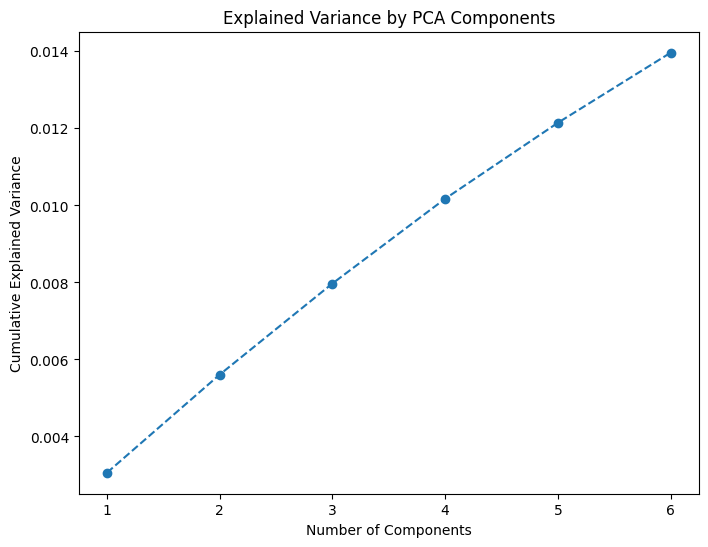

In [66]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

imputer = SimpleImputer(strategy="mean")  
scaled_data = imputer.fit_transform(scaled_data)

pca = PCA(n_components=6)  
pca_features = pca.fit_transform(scaled_data)

# Convert to DataFrame
pca_df = pd.DataFrame(pca_features, columns=[f'PC{i+1}' for i in range(6)])

explained_variance = pca.explained_variance_ratio_

# Plot cumulative variance
plt.figure(figsize=(8,6))
plt.plot(range(1, len(explained_variance)+1), explained_variance.cumsum(), marker='o', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()